In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def report(name, y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    ap = average_precision_score(y_true, proba) if proba is not None else float('nan')
    print(f'[{name}] Acc={acc:.4f} | P={prec:.4f} | R={rec:.4f} | F1={f1:.4f} | AUC-PR={ap:.4f}')

# 1. Data Preparation

In [3]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("Dataset shape:", df.shape)
print("Head:\n", df.head(3))
print("\nTarget distribution:")
print(df['y'].value_counts(normalize=True))

Dataset shape: (41188, 21)
Head:
    age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y  
0          93.994          -36.4      4.857       5191.0  no  
1          93.994          -36.4      4.857       5191.0  no  
2          93.994          -36.4      4.857       5191.0  no  

[3 rows x 21 columns]

Target distribution:
y
no     0.887346
yes    0.112654
Name:

In [4]:
print("'unknown' counts per column:")
for col in df.select_dtypes(include='object').columns:
    unk = (df[col] == 'unknown').sum()
    if unk > 0:
        print(f"  {col}: {unk} ({unk/len(df)*100:.1f}%)")

'unknown' counts per column:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


In [5]:
df['y'] = (df['y'] == 'yes').astype(int)

X = df.drop(columns=['y'])
y = df['y']

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Target balance (train): {y_train.mean():.3f} positive")

Train: 28831, Val: 6178, Test: 6179
Target balance (train): 0.113 positive


In [6]:
X_train = X_train.drop(columns=['default'])
X_val = X_val.drop(columns=['default'])
X_test = X_test.drop(columns=['default'])

unknown_cols = ['job', 'marital', 'education', 'housing', 'loan']

modes = {}
for col in unknown_cols:
    modes[col] = X_train[X_train[col] != 'unknown'][col].mode()[0]
    print(f"  {col}: impute 'unknown' -> '{modes[col]}'")

for col in unknown_cols:
    X_train[col] = X_train[col].replace('unknown', modes[col])
    X_val[col] = X_val[col].replace('unknown', modes[col])
    X_test[col] = X_test[col].replace('unknown', modes[col])

  job: impute 'unknown' -> 'admin.'
  marital: impute 'unknown' -> 'married'
  education: impute 'unknown' -> 'university.degree'
  housing: impute 'unknown' -> 'yes'
  loan: impute 'unknown' -> 'no'


In [7]:
categorical_cols = ['job', 'marital', 'education', 'housing', 'loan',
                    'contact', 'month', 'day_of_week', 'poutcome']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[categorical_cols])

def encode_and_merge(X, ohe, cat_cols):
    encoded = pd.DataFrame(
        ohe.transform(X[cat_cols]),
        columns=ohe.get_feature_names_out(cat_cols),
        index=X.index
    )
    return pd.concat([X.drop(columns=cat_cols), encoded], axis=1)

X_train = encode_and_merge(X_train, ohe, categorical_cols)
X_val = encode_and_merge(X_val, ohe, categorical_cols)
X_test = encode_and_merge(X_test, ohe, categorical_cols)

print("Transformed shapes:", X_train.shape, X_val.shape, X_test.shape)

Transformed shapes: (28831, 55) (6178, 55) (6179, 55)


In [8]:
continuous_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                   'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                   'euribor3m', 'nr.employed']

scaler = StandardScaler()
scaler.fit(X_train[continuous_cols])

X_train[continuous_cols] = scaler.transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

# 2. Gradient Boosted Tree (GBDT)

In [9]:
results = {}

for lr in [0.01, 0.1, 0.3]:
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        learning_rate=lr,
        n_estimators=500,
        max_depth=6,
        subsample=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0,
        early_stopping_rounds=20,
        random_state=42,
        n_jobs=-1
    )
    start = time.time()
    model.fit(X_train, y_train,
              eval_set=[(X_train, y_train), (X_val, y_val)],
              verbose=False)
    train_time = time.time() - start

    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    results[f"XGB (lr={lr})"] = {
        'model': model, 'y_pred': y_pred, 'proba': proba, 'time': train_time
    }

    print(f"\n=== XGB (lr={lr}) ===")
    print(f"Stopped at round {model.best_iteration} | Train time: {train_time:.1f}s")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes'], digits=3))


=== XGB (lr=0.01) ===
Stopped at round 496 | Train time: 13.5s
              precision    recall  f1-score   support

          No      0.945     0.966     0.956      5483
         Yes      0.677     0.560     0.613       696

    accuracy                          0.920      6179
   macro avg      0.811     0.763     0.784      6179
weighted avg      0.915     0.920     0.917      6179


=== XGB (lr=0.1) ===
Stopped at round 64 | Train time: 2.5s
              precision    recall  f1-score   support

          No      0.946     0.964     0.955      5483
         Yes      0.668     0.570     0.616       696

    accuracy                          0.920      6179
   macro avg      0.807     0.767     0.785      6179
weighted avg      0.915     0.920     0.917      6179


=== XGB (lr=0.3) ===
Stopped at round 24 | Train time: 2.2s
              precision    recall  f1-score   support

          No      0.945     0.964     0.955      5483
         Yes      0.664     0.562     0.609       6

### Effect of Learning Rate

In [12]:
print("=" * 80)
print("Effect of Learning Rate on XGBoost")
print("=" * 80)
for name in ["XGB (lr=0.01)", "XGB (lr=0.1)", "XGB (lr=0.3)"]:
    res = results[name]
    report(name, y_test, res['y_pred'], proba=res['proba'])

Effect of Learning Rate on XGBoost
[XGB (lr=0.01)] Acc=0.9204 | P=0.6771 | R=0.5603 | F1=0.6132 | AUC-PR=0.6630
[XGB (lr=0.1)] Acc=0.9197 | P=0.6684 | R=0.5704 | F1=0.6155 | AUC-PR=0.6626
[XGB (lr=0.3)] Acc=0.9186 | P=0.6638 | R=0.5618 | F1=0.6086 | AUC-PR=0.6568


### Explore Other Hyperparameters

In [14]:
for n in [50, 100, 300, 500]:
    model = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        learning_rate=0.1, n_estimators=n, max_depth=6,
        subsample=0.9, reg_lambda=1.0, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    results[f"XGB (n_est={n})"] = {'y_pred': y_pred, 'proba': proba}

print("=" * 80)
print("Effect of n_estimators")
print("=" * 80)
for n in [50, 100, 300, 500]:
    res = results[f"XGB (n_est={n})"]
    report(f"XGB (n_est={n})", y_test, res['y_pred'], proba=res['proba'])

Effect of n_estimators
[XGB (n_est=50)] Acc=0.9205 | P=0.6783 | R=0.5603 | F1=0.6137 | AUC-PR=0.6626
[XGB (n_est=100)] Acc=0.9197 | P=0.6712 | R=0.5632 | F1=0.6125 | AUC-PR=0.6576
[XGB (n_est=300)] Acc=0.9155 | P=0.6445 | R=0.5575 | F1=0.5978 | AUC-PR=0.6320
[XGB (n_est=500)] Acc=0.9097 | P=0.6117 | R=0.5431 | F1=0.5753 | AUC-PR=0.6224


In [15]:
for depth in [3, 6, 10]:
    model = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        learning_rate=0.1, n_estimators=300, max_depth=depth,
        subsample=0.9, reg_lambda=1.0, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    results[f"XGB (depth={depth})"] = {'y_pred': y_pred, 'proba': proba}

print("=" * 80)
print("Effect of max_depth")
print("=" * 80)
for depth in [3, 6, 10]:
    res = results[f"XGB (depth={depth})"]
    report(f"XGB (depth={depth})", y_test, res['y_pred'], proba=res['proba'])

Effect of max_depth
[XGB (depth=3)] Acc=0.9167 | P=0.6563 | R=0.5460 | F1=0.5961 | AUC-PR=0.6499
[XGB (depth=6)] Acc=0.9155 | P=0.6445 | R=0.5575 | F1=0.5978 | AUC-PR=0.6320
[XGB (depth=10)] Acc=0.9089 | P=0.6044 | R=0.5532 | F1=0.5776 | AUC-PR=0.6044


In [16]:
for ss in [0.5, 0.7, 0.9, 1.0]:
    model = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        learning_rate=0.1, n_estimators=300, max_depth=6,
        subsample=ss, reg_lambda=1.0, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    results[f"XGB (subsample={ss})"] = {'y_pred': y_pred, 'proba': proba}

print("=" * 80)
print("Effect of subsample")
print("=" * 80)
for ss in [0.5, 0.7, 0.9, 1.0]:
    res = results[f"XGB (subsample={ss})"]
    report(f"XGB (subsample={ss})", y_test, res['y_pred'], proba=res['proba'])

Effect of subsample
[XGB (subsample=0.5)] Acc=0.9099 | P=0.6134 | R=0.5402 | F1=0.5745 | AUC-PR=0.6035
[XGB (subsample=0.7)] Acc=0.9112 | P=0.6203 | R=0.5445 | F1=0.5800 | AUC-PR=0.6140
[XGB (subsample=0.9)] Acc=0.9155 | P=0.6445 | R=0.5575 | F1=0.5978 | AUC-PR=0.6320
[XGB (subsample=1.0)] Acc=0.9150 | P=0.6457 | R=0.5445 | F1=0.5908 | AUC-PR=0.6353


In [18]:
for alpha, lam in [(0, 0), (0.1, 1.0), (1.0, 5.0)]:
    model = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        learning_rate=0.1, n_estimators=300, max_depth=6,
        subsample=0.9, reg_alpha=alpha, reg_lambda=lam,
        random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    results[f"XGB (a={alpha},l={lam})"] = {'y_pred': y_pred, 'proba': proba}

print("=" * 80)
print("Effect of Regularization (reg_alpha, reg_lambda)")
print("=" * 80)
for alpha, lam in [(0, 0), (0.1, 1.0), (1.0, 5.0)]:
    res = results[f"XGB (a={alpha},l={lam})"]
    report(f"XGB (a={alpha},l={lam})", y_test, res['y_pred'], proba=res['proba'])

Effect of Regularization (reg_alpha, reg_lambda)
[XGB (a=0,l=0)] Acc=0.9147 | P=0.6401 | R=0.5546 | F1=0.5943 | AUC-PR=0.6303
[XGB (a=0.1,l=1.0)] Acc=0.9155 | P=0.6422 | R=0.5647 | F1=0.6009 | AUC-PR=0.6301
[XGB (a=1.0,l=5.0)] Acc=0.9116 | P=0.6234 | R=0.5445 | F1=0.5813 | AUC-PR=0.6363


### Hyperparameter Search

In [17]:
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 6, 8, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 1.0, 5.0],
    'n_estimators': [100, 300, 500]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)
print("Best GBDT params:", xgb_search.best_params_)
print("Best CV F1:", f"{xgb_search.best_score_:.4f}")

Best GBDT params: {'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}
Best CV F1: 0.5827


### Training vs. Validation Loss

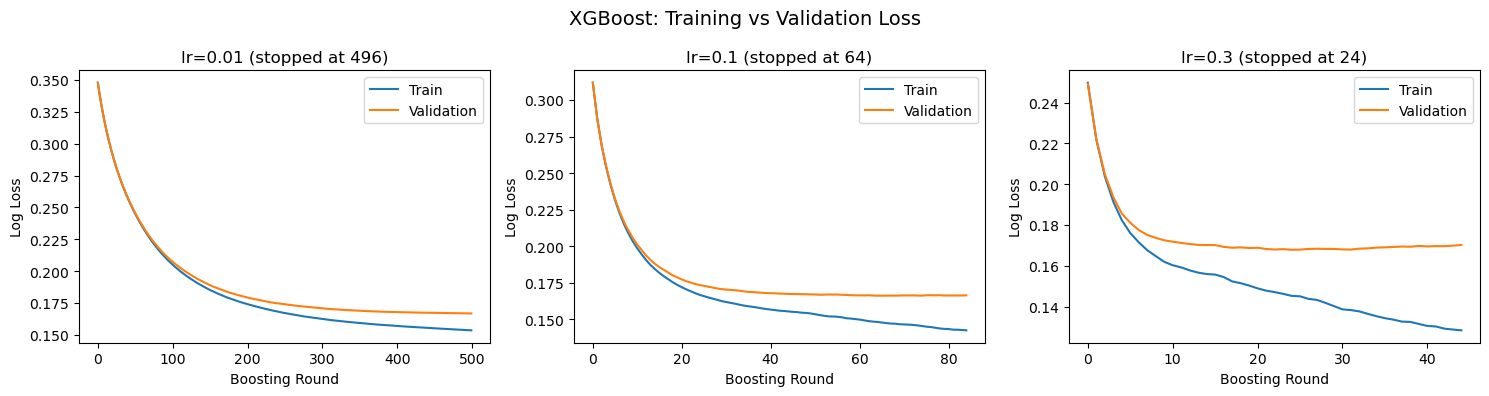

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lr in zip(axes, [0.01, 0.1, 0.3]):
    model = results[f"XGB (lr={lr})"]['model']
    evals = model.evals_result()
    ax.plot(evals['validation_0']['logloss'], label='Train')
    ax.plot(evals['validation_1']['logloss'], label='Validation')
    ax.set_title(f'lr={lr} (stopped at {model.best_iteration})')
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel('Log Loss')
    ax.legend()

plt.suptitle('XGBoost: Training vs Validation Loss', fontsize=14)
plt.tight_layout()
plt.show()

### Feature Importance

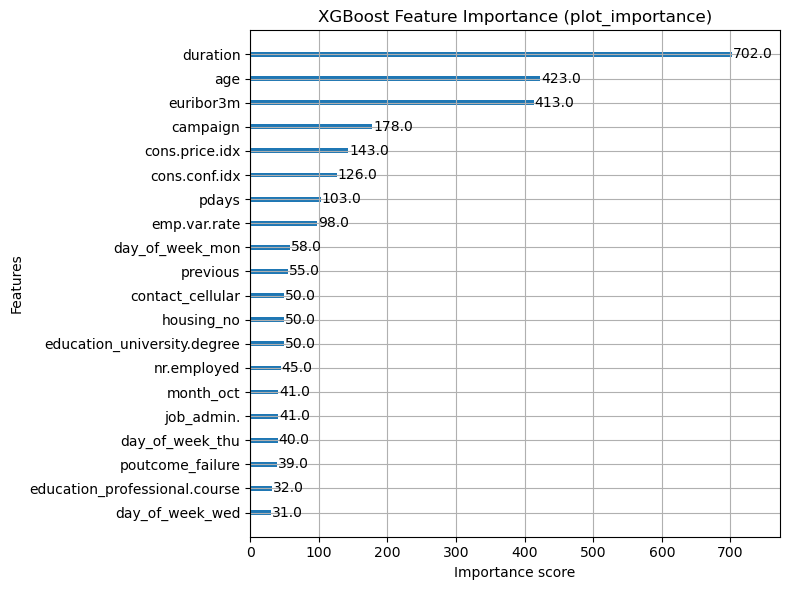

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
xgb.plot_importance(results["XGB (lr=0.1)"]['model'], max_num_features=20, ax=ax)
plt.title('XGBoost Feature Importance (plot_importance)')
plt.tight_layout()
plt.show()

### Effect of Learning Rate Visualization

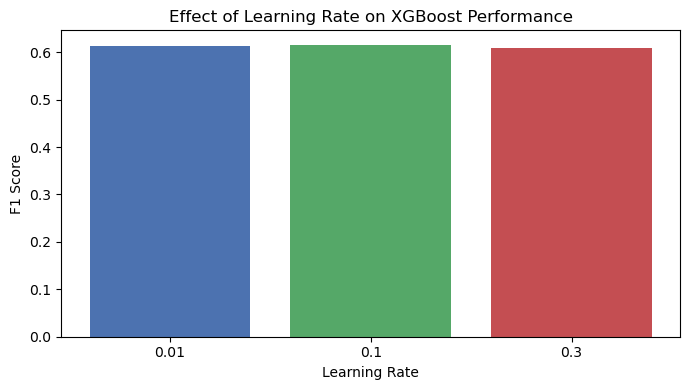

In [13]:
lr_names = ["XGB (lr=0.01)", "XGB (lr=0.1)", "XGB (lr=0.3)"]
lr_f1s = [f1_score(y_test, results[n]['y_pred']) for n in lr_names]

plt.figure(figsize=(7, 4))
plt.bar(['0.01', '0.1', '0.3'], lr_f1s, color=['#4C72B0', '#55A868', '#C44E52'])
plt.xlabel('Learning Rate')
plt.ylabel('F1 Score')
plt.title('Effect of Learning Rate on XGBoost Performance')
plt.tight_layout()
plt.show()

# 3. Multi-Layer Perceptron (MLP)

In [19]:
for layers in [(64,), (128, 64), (256, 128, 64)]:
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    )
    start = time.time()
    mlp.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = mlp.predict(X_test)
    proba = mlp.predict_proba(X_test)[:,1]
    results[f"MLP {layers}"] = {
        'model': mlp, 'y_pred': y_pred, 'proba': proba, 'time': train_time
    }

print("=" * 80)
print("Effect of Network Depth/Width")
print("=" * 80)
for layers in [(64,), (128, 64), (256, 128, 64)]:
    res = results[f"MLP {layers}"]
    report(f"MLP {layers}", y_test, res['y_pred'], proba=res['proba'])

Effect of Network Depth/Width
[MLP (64,)] Acc=0.9165 | P=0.6654 | R=0.5201 | F1=0.5839 | AUC-PR=0.6312
[MLP (128, 64)] Acc=0.9162 | P=0.6561 | R=0.5374 | F1=0.5908 | AUC-PR=0.6410
[MLP (256, 128, 64)] Acc=0.9110 | P=0.6113 | R=0.5761 | F1=0.5932 | AUC-PR=0.6349


In [20]:
for act in ['relu', 'tanh']:
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation=act,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    proba = mlp.predict_proba(X_test)[:,1]
    results[f"MLP relu vs tanh ({act})"] = {
        'model': mlp, 'y_pred': y_pred, 'proba': proba
    }

print("=" * 80)
print("Effect of Activation Function")
print("=" * 80)
for act in ['relu', 'tanh']:
    res = results[f"MLP relu vs tanh ({act})"]
    report(f"MLP ({act})", y_test, res['y_pred'], proba=res['proba'])

Effect of Activation Function
[MLP (relu)] Acc=0.9162 | P=0.6561 | R=0.5374 | F1=0.5908 | AUC-PR=0.6410
[MLP (tanh)] Acc=0.9165 | P=0.6679 | R=0.5144 | F1=0.5812 | AUC-PR=0.6435


In [21]:
for lr in [0.001, 0.01, 0.1]:
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        learning_rate_init=lr,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    proba = mlp.predict_proba(X_test)[:,1]
    results[f"MLP (lr_init={lr})"] = {
        'model': mlp, 'y_pred': y_pred, 'proba': proba
    }

print("=" * 80)
print("Effect of Learning Rate")
print("=" * 80)
for lr in [0.001, 0.01, 0.1]:
    res = results[f"MLP (lr_init={lr})"]
    report(f"MLP (lr_init={lr})", y_test, res['y_pred'], proba=res['proba'])

Effect of Learning Rate
[MLP (lr_init=0.001)] Acc=0.9162 | P=0.6561 | R=0.5374 | F1=0.5908 | AUC-PR=0.6410
[MLP (lr_init=0.01)] Acc=0.9168 | P=0.6440 | R=0.5848 | F1=0.6130 | AUC-PR=0.6540
[MLP (lr_init=0.1)] Acc=0.9095 | P=0.6089 | R=0.5503 | F1=0.5781 | AUC-PR=0.5792


In [22]:
for mi in [50, 100, 200, 300]:
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=mi,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    proba = mlp.predict_proba(X_test)[:,1]
    results[f"MLP (max_iter={mi})"] = {
        'model': mlp, 'y_pred': y_pred, 'proba': proba
    }

print("=" * 80)
print("Effect of max_iter")
print("=" * 80)
for mi in [50, 100, 200, 300]:
    res = results[f"MLP (max_iter={mi})"]
    report(f"MLP (max_iter={mi})", y_test, res['y_pred'], proba=res['proba'])

Effect of max_iter
[MLP (max_iter=50)] Acc=0.9162 | P=0.6561 | R=0.5374 | F1=0.5908 | AUC-PR=0.6410
[MLP (max_iter=100)] Acc=0.9162 | P=0.6561 | R=0.5374 | F1=0.5908 | AUC-PR=0.6410
[MLP (max_iter=200)] Acc=0.9162 | P=0.6561 | R=0.5374 | F1=0.5908 | AUC-PR=0.6410
[MLP (max_iter=300)] Acc=0.9162 | P=0.6561 | R=0.5374 | F1=0.5908 | AUC-PR=0.6410


### Training Loss Curves

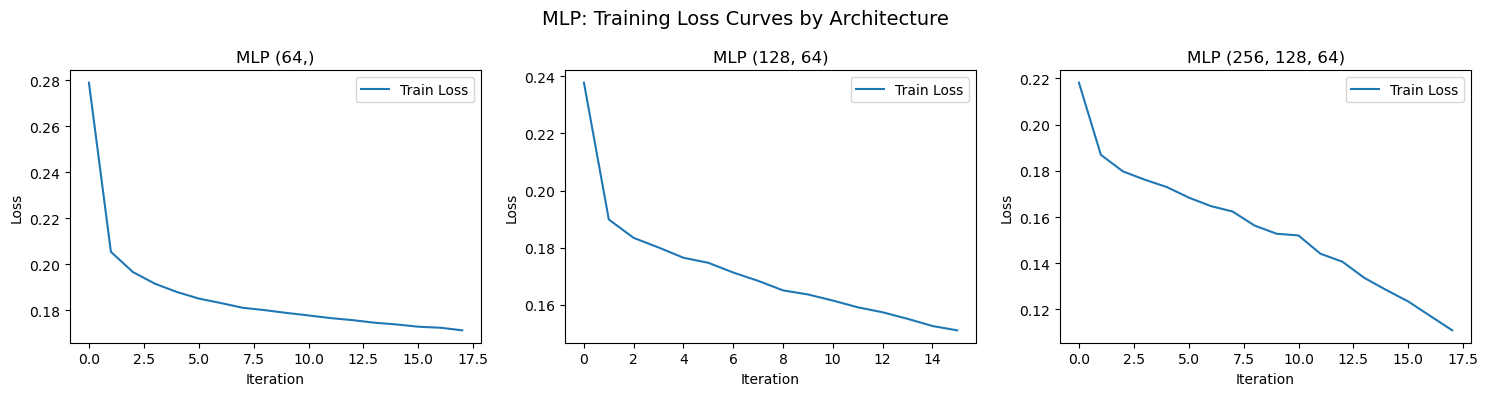

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, layers in zip(axes, [(64,), (128, 64), (256, 128, 64)]):
    mlp = results[f"MLP {layers}"]['model']
    ax.plot(mlp.loss_curve_, label='Train Loss')
    ax.set_title(f'MLP {layers}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('MLP: Training Loss Curves by Architecture', fontsize=14)
plt.tight_layout()
plt.show()

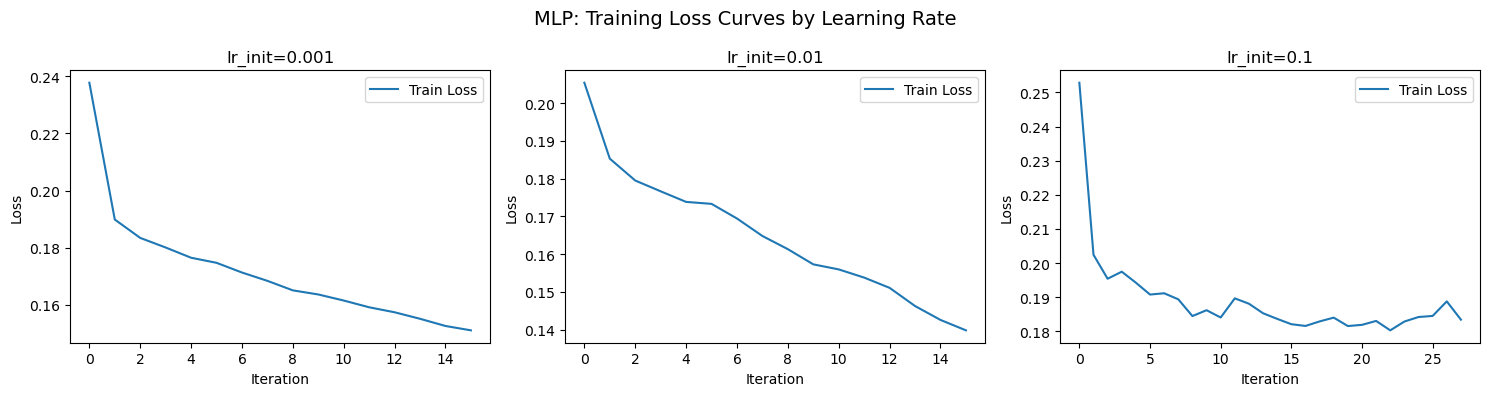

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, lr in zip(axes, [0.001, 0.01, 0.1]):
    mlp = results[f"MLP (lr_init={lr})"]['model']
    ax.plot(mlp.loss_curve_, label='Train Loss')
    ax.set_title(f'lr_init={lr}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('MLP: Training Loss Curves by Learning Rate', fontsize=14)
plt.tight_layout()
plt.show()

### Effect of Network Depth/Width on Validation Performance

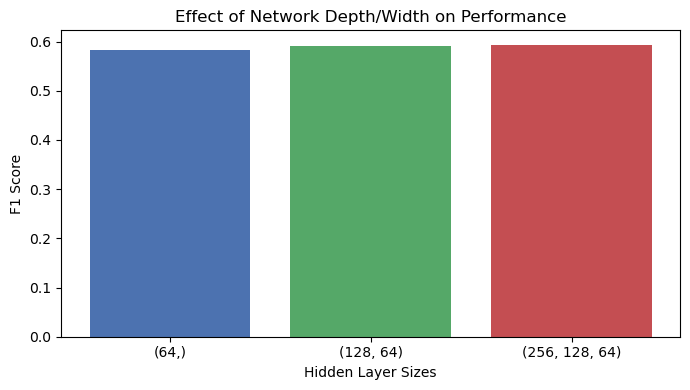

In [25]:
layer_configs = [(64,), (128, 64), (256, 128, 64)]
val_f1s = []
for layers in layer_configs:
    res = results[f"MLP {layers}"]
    val_f1s.append(f1_score(y_test, res['y_pred']))

plt.figure(figsize=(7, 4))
plt.bar([str(l) for l in layer_configs], val_f1s, color=['#4C72B0', '#55A868', '#C44E52'])
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('F1 Score')
plt.title('Effect of Network Depth/Width on Performance')
plt.tight_layout()
plt.show()

# 4. GBDT vs MLP Comparison

In [26]:
best_xgb_name = "XGB (lr=0.1)"
best_mlp_name = "MLP (128, 64)"

print("=" * 80)
print("GBDT vs MLP: Final Comparison")
print("=" * 80)
report(best_xgb_name, y_test, results[best_xgb_name]['y_pred'], proba=results[best_xgb_name]['proba'])
report(best_mlp_name, y_test, results[best_mlp_name]['y_pred'], proba=results[best_mlp_name]['proba'])

print("\nDetailed classification reports:")
for name in [best_xgb_name, best_mlp_name]:
    print(f"\n=== {name} ===")
    print(classification_report(y_test, results[name]['y_pred'], target_names=['No', 'Yes'], digits=3))

GBDT vs MLP: Final Comparison
[XGB (lr=0.1)] Acc=0.9197 | P=0.6684 | R=0.5704 | F1=0.6155 | AUC-PR=0.6626
[MLP (128, 64)] Acc=0.9162 | P=0.6561 | R=0.5374 | F1=0.5908 | AUC-PR=0.6410

Detailed classification reports:

=== XGB (lr=0.1) ===
              precision    recall  f1-score   support

          No      0.946     0.964     0.955      5483
         Yes      0.668     0.570     0.616       696

    accuracy                          0.920      6179
   macro avg      0.807     0.767     0.785      6179
weighted avg      0.915     0.920     0.917      6179


=== MLP (128, 64) ===
              precision    recall  f1-score   support

          No      0.943     0.964     0.953      5483
         Yes      0.656     0.537     0.591       696

    accuracy                          0.916      6179
   macro avg      0.799     0.751     0.772      6179
weighted avg      0.910     0.916     0.912      6179



In [27]:
xgb_cv_model = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='logloss',
    learning_rate=0.1, n_estimators=300, max_depth=6,
    subsample=0.9, reg_lambda=1.0, random_state=42, n_jobs=-1
)
xgb_cv = cross_val_score(xgb_cv_model, X_train, y_train, cv=5, scoring='f1')
print(f"XGB 5-fold CV F1: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

mlp_cv_model = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation='relu',
    learning_rate_init=0.001, max_iter=300, random_state=42
)
mlp_cv = cross_val_score(mlp_cv_model, X_train, y_train, cv=5, scoring='f1')
print(f"MLP 5-fold CV F1: {mlp_cv.mean():.4f} ± {mlp_cv.std():.4f}")

XGB 5-fold CV F1: 0.5799 ± 0.0184
MLP 5-fold CV F1: 0.5149 ± 0.0254


In [28]:
rows = []
for name in [best_xgb_name, best_mlp_name]:
    res = results[name]
    rows.append({
        'Model': name,
        'Accuracy': f"{accuracy_score(y_test, res['y_pred']):.4f}",
        'Precision': f"{precision_score(y_test, res['y_pred']):.4f}",
        'Recall': f"{recall_score(y_test, res['y_pred']):.4f}",
        'F1': f"{f1_score(y_test, res['y_pred']):.4f}",
        'AUC-PR': f"{average_precision_score(y_test, res['proba']):.4f}",
        'Train Time (s)': f"{res['time']:.2f}"
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print("\nSummary comparison:\n")
print(comparison_df.to_string())


Summary comparison:

              Accuracy Precision  Recall      F1  AUC-PR Train Time (s)
Model                                                                  
XGB (lr=0.1)    0.9197    0.6684  0.5704  0.6155  0.6626           2.50
MLP (128, 64)   0.9162    0.6561  0.5374  0.5908  0.6410          12.91


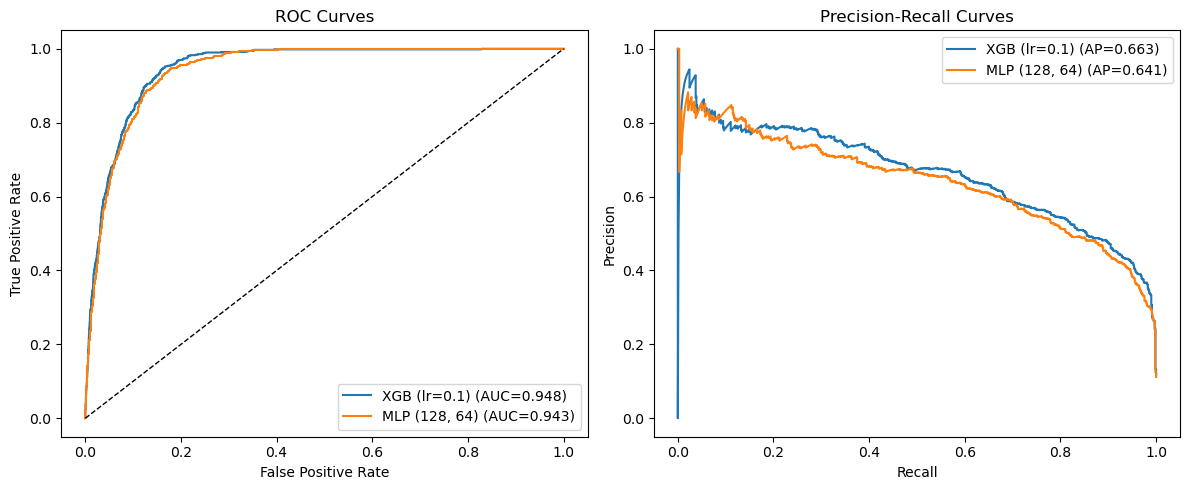

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
ax = axes[0]
for name in [best_xgb_name, best_mlp_name]:
    fpr, tpr, _ = roc_curve(y_test, results[name]['proba'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()

# PR
ax = axes[1]
for name in [best_xgb_name, best_mlp_name]:
    prec, rec, _ = precision_recall_curve(y_test, results[name]['proba'])
    ap = average_precision_score(y_test, results[name]['proba'])
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()

plt.tight_layout()
plt.show()

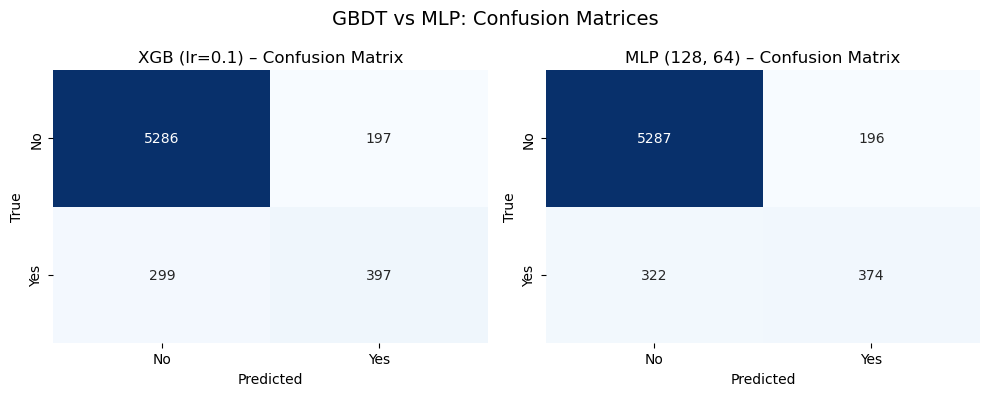

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, [best_xgb_name, best_mlp_name]):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f"{name} – Confusion Matrix")

plt.suptitle('GBDT vs MLP: Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()